# Red bayesiana - Titanic

Objetivo: entrenar una red bayesiana y evaluar en entrenamiento y prueba.

## 1) Librerias

In [47]:
!pip install pandas matplotlib seaborn scikit-learn pyagrum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 4.2 MB/s  0:00:01m 4.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pyagrum]━━━ 1/2 [pyagrum]


In [93]:
# Datos
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report, roc_auc_score, roc_curve

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import pyagrum.skbn as skbn
import pyagrum.lib.notebook as gnb

from sklearn import set_config
set_config(transform_output = "pandas")

## 2) Cargar datos

In [94]:
# Esto se debe cambiar por la ruta correcta del dataset
# Leer archivo
data = pd.read_csv("titanic.csv")


In [95]:
# Vista rapida
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [96]:
# Tipos de columnas
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 3) Preparar datos

In [97]:
# NOTA: Deben cambiar esto por los que correspondan a su dataset.

variables_a_descartar = ["PassengerId", "Name", "Cabin", "Ticket"]

variables_categoricas = ["Sex", "Embarked"]
variables_numericas = ["Pclass", "SibSp", "Parch", "Fare", "Age"]
variables_ordinales = ["Pclass"]  # Ejemplo de variable ordinal (es como una categorica pero tiene orden), ajusten según su dataset

 # Descartamos variables que no deberian aportar informacion, o que
 # al contrario, pueden aportar información pero tienen muchos valores únicos,
 # lo que dificulta su uso directo en modelos de machine learning.
variable_dependiente = "Survived"

In [98]:
for var in variables_categoricas:
    data[var] = data[var].astype("category")

In [99]:
# Deben elegir uno de estos caminos

# Eliminar faltantes clave (si es que hay)
# datos_modelo = titanic.dropna(subset=["Age", "Embarked"])

# Imputar faltantes (si es que hay)
# titanic["Age"].fillna(titanic["Age"].median(), inplace=True)

In [100]:
# Resumen
data.describe(include="all")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [101]:
X = data.drop([variable_dependiente] + variables_a_descartar, axis=1)
y = data[variable_dependiente]

In [102]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [103]:
# Puede que su variable dependiente no esté en formato numérico, lo que es necesario para la red bayesiana. 
# En ese caso, deben convertirla a numérica. Por ejemplo, si "Survived" es categórica, pueden hacer lo siguiente:
# Ajusta según los valores reales de tu variable dependiente
# y = y.map({"No": 0, "Yes": 1})  

## 4) Separar entrenamiento y prueba (80/20)

In [104]:
random_state = 42 # Esta semilla asegura que los resultados sean reproducibles

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

## 5) Variables para red bayesiana (discretización + inferencia probabilística)

In [106]:
modelo=skbn.BNClassifier()

pipeline = Pipeline([
    ("preprocesamiento", ColumnTransformer([
        ("numerico", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),  # Imputar valores faltantes
            ("scaler", StandardScaler()),
        ]), variables_numericas),
        ("categorico", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),  # Imputar valores faltantes
            ("encoder", OneHotEncoder(sparse_output=False, drop="first")) # Se bota la primera categoría para evitar multicolinealidad
        ]), variables_categoricas)
    ])),
])  # Asegura que la salida sea un DataFrame de pandas

## 6) Entrenar y predecir

In [107]:
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)

In [108]:
X_train_transformed

,numerico__Pclass,numerico__SibSp,numerico__Parch,numerico__Fare,numerico__Age,categorico__Sex_male,categorico__Embarked_Q,categorico__Embarked_S
331,-1.614136,-0.470722,-0.479342,-0.078684,1.232263e+00,1.0,0.0,1.0
733,-0.400551,-0.470722,-0.479342,-0.377145,-5.004820e-01,1.0,0.0,1.0
382,0.813034,-0.470722,-0.479342,-0.474867,1.926161e-01,1.0,0.0,1.0
704,0.813034,0.379923,-0.479342,-0.476230,-2.694493e-01,1.0,0.0,1.0
813,0.813034,2.931860,2.048742,-0.025249,-1.809667e+00,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
106,0.813034,-0.470722,-0.479342,-0.480162,-6.545038e-01,0.0,0.0,1.0
270,-1.614136,-0.470722,-0.479342,-0.030545,2.735977e-16,1.0,0.0,1.0
860,0.813034,1.230569,-0.479342,-0.355804,8.857142e-01,1.0,0.0,1.0
435,-1.614136,0.379923,2.048742,1.683201,-1.193580e+00,0.0,0.0,1.0


In [109]:
modelo.fit(X_train_transformed, y_train)

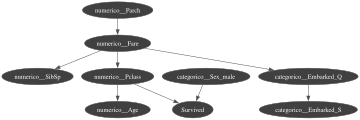

In [110]:
gnb.showBN(modelo.bn)

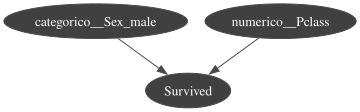

In [111]:
gnb.showBN(modelo.MarkovBlanket)

In [112]:
umbral = 0.5 # Este umbral puede ajustarse según las necesidades del problema, pero 0.5 es un punto de partida común.
umbral = y_train.mean()  # Por ejemplo, usar la media de la variable dependiente como umbral

In [113]:
# Prediccion entrenamiento
y_train_pred = modelo.predict_proba(X_train_transformed)[:, 1]  # Probabilidad de la clase positiva
y_train_pred_class = y_train_pred >= umbral  # Convertir a clase binaria usando un umbral basado en la media de la variable dependiente


In [114]:
# Prediccion prueba
y_test_pred = modelo.predict_proba(X_test_transformed)[:, 1]  # Probabilidad de la clase positiva
y_test_pred_class = y_test_pred >= umbral  # Convertir a clase binaria usando un umbral basado en la media de la variable dependiente


## 7) Evaluacion

In [115]:
# Matriz de confusion entrenamiento
cm = confusion_matrix(y_test, y_test_pred_class)
pd.DataFrame(cm, index=['Real_0', 'Real_1'], columns=['Pred_0', 'Pred_1'])


,Pred_0,Pred_1
Real_0,88,17
Real_1,22,52


In [116]:
# Reporte de clasificacion
print(classification_report(y_test, y_test_pred_class, digits=4, zero_division=0))


              precision    recall  f1-score   support

           0     0.8000    0.8381    0.8186       105
           1     0.7536    0.7027    0.7273        74

    accuracy                         0.7821       179
   macro avg     0.7768    0.7704    0.7729       179
weighted avg     0.7808    0.7821    0.7808       179



In [117]:
# Matriz de confusion prueba
cm = confusion_matrix(y_test, y_test_pred_class)
pd.DataFrame(cm, index=['Real_0', 'Real_1'], columns=['Pred_0', 'Pred_1'])


,Pred_0,Pred_1
Real_0,88,17
Real_1,22,52


In [118]:
# Reporte de clasificacion
print(classification_report(y_test, y_test_pred_class, digits=4, zero_division=0))


              precision    recall  f1-score   support

           0     0.8000    0.8381    0.8186       105
           1     0.7536    0.7027    0.7273        74

    accuracy                         0.7821       179
   macro avg     0.7768    0.7704    0.7729       179
weighted avg     0.7808    0.7821    0.7808       179



In [119]:
# Metricas respecto a clase 1 (la clase positiva)
train_accuracy = accuracy_score(y_train, y_train_pred_class)
test_accuracy = accuracy_score(y_test, y_test_pred_class)
train_recall = recall_score(y_train, y_train_pred_class, zero_division=0)
test_recall = recall_score(y_test, y_test_pred_class, zero_division=0)
train_precision = precision_score(y_train, y_train_pred_class, zero_division=0)
test_precision = precision_score(y_test, y_test_pred_class, zero_division=0)
train_auroc = roc_auc_score(y_train, y_train_pred)
test_auroc = roc_auc_score(y_test, y_test_pred)

print (f"Accuracy entrenamiento: {train_accuracy:.4f}")
print (f"Accuracy prueba: {test_accuracy:.4f}")
print (f"Recall entrenamiento: {train_recall:.4f}")
print (f"Recall prueba: {test_recall:.4f}")
print (f"Precision entrenamiento: {train_precision:.4f}")
print (f"Precision prueba: {test_precision:.4f}")
print (f"AUROC entrenamiento: {train_auroc:.4f}")
print (f"AUROC prueba: {test_auroc:.4f}")

Accuracy entrenamiento: 0.7879
Accuracy prueba: 0.7821
Recall entrenamiento: 0.6754
Recall prueba: 0.7027
Precision entrenamiento: 0.7388
Precision prueba: 0.7536
AUROC entrenamiento: 0.8269
AUROC prueba: 0.8418


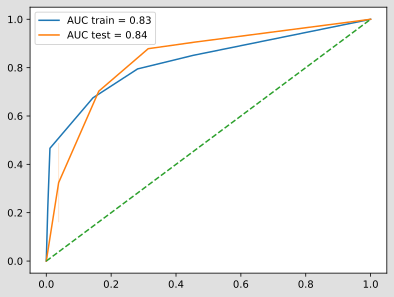

In [120]:
train_roc_fpr, train_roc_tpr, train_roc_thresholds = roc_curve(y_train, y_train_pred)
test_roc_fpr, test_roc_tpr, test_roc_thresholds = roc_curve(y_test, y_test_pred)

plt.figure()
sns.lineplot(x=train_roc_fpr, y=train_roc_tpr, label=f"AUC train = {train_auroc:.2f}")
sns.lineplot(x=test_roc_fpr, y=test_roc_tpr, label=f"AUC test = {test_auroc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier